In [ ]:
Reducción de Dimensionalidad con PCA

Paso 1 - Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Paso 2 - Cargar el dataset limpio

In [5]:
from google.colab import files

uploaded = files.upload()

Saving streaming_users_clean (2).json to streaming_users_clean (2).json


In [6]:
df = pd.read_json("streaming_users_clean (2).json")

Paso 3 - Seleccionar las variables numéricas

In [7]:
variables = df.select_dtypes(include=["int64","float64"])

variables.head()

,user_id,age,monthly_watch_time_mins,customer_support_tickets
0,10000,39,805.8,99
1,10001,37,1173.4,2
2,10002,28,401.0,0
3,10003,43,62.4,0
4,10004,51,477.8,1


Paso 4 - Escalar los datos

In [9]:
scaler = StandardScaler()

datos_escalados = scaler.fit_transform(variables)

Paso 5 - Aplicar PCA

In [10]:
pca = PCA()

componentes = pca.fit_transform(datos_escalados)

Paso 6 - Varianza explicada

In [11]:
varianza = pca.explained_variance_ratio_

print(varianza)

[0.25518684 0.25086566 0.24819145 0.24575605]


La varianza explicada indica cuánta información conserva cada componente principal. Cuanto mayor sea este valor, mayor será la cantidad de información representada por ese componente.

Paso 7 - Gráfico de la varianza explicada

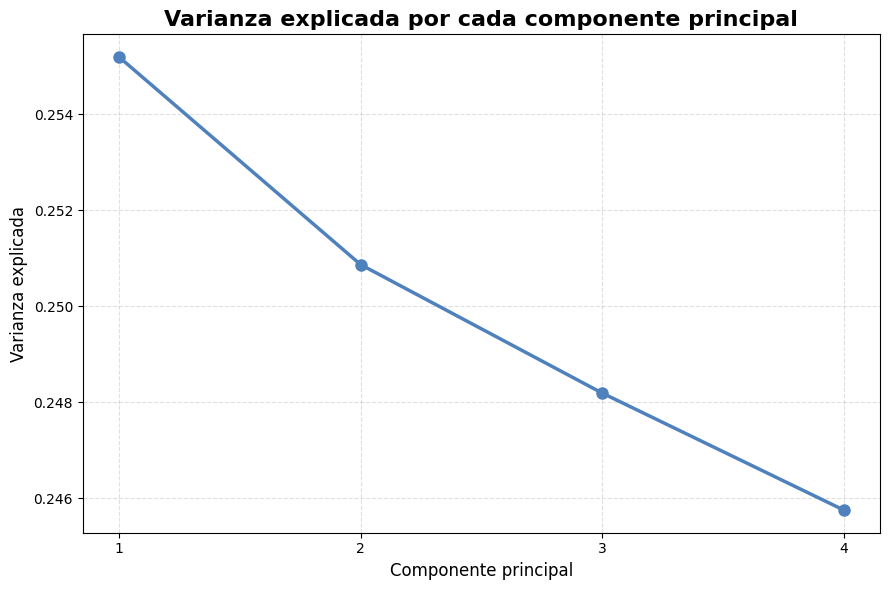

In [18]:
# Obtener la varianza explicada
varianza = pca.explained_variance_ratio_

# Crear el gráfico
plt.figure(figsize=(9,6))

plt.plot(
    range(1, len(varianza) + 1),
    varianza,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#4F81BD"
)

plt.title(
    "Varianza explicada por cada componente principal",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Componente principal", fontsize=12)
plt.ylabel("Varianza explicada", fontsize=12)

plt.xticks(range(1, len(varianza) + 1))

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

El gráfico muestra la cantidad de información que conserva cada componente principal. Generalmente, las primeras componentes explican la mayor parte de la variabilidad de los datos, mientras que las restantes aportan una cantidad menor de información.

Paso 8 - Gráfico de Importancia de las variables en la primera componente

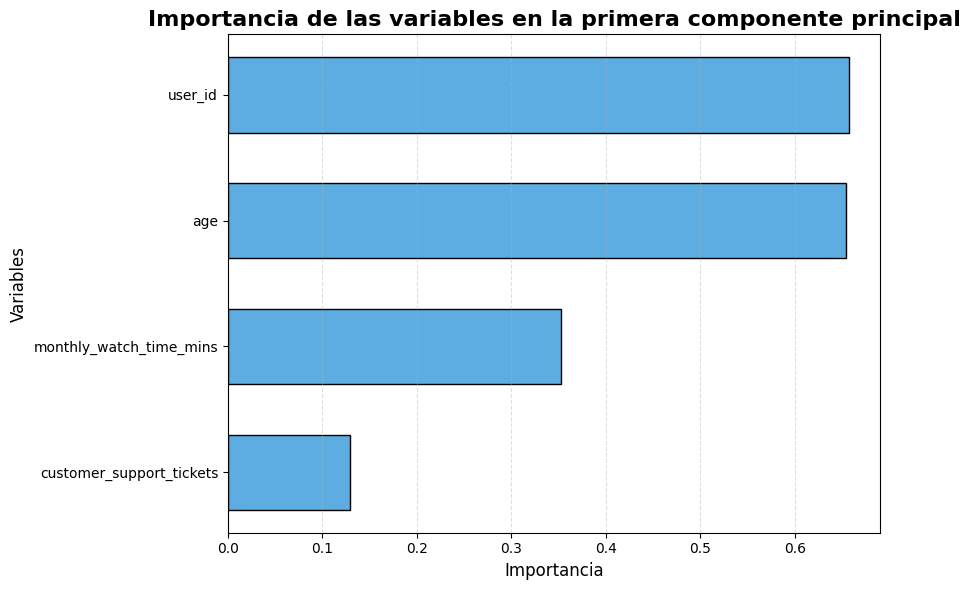

In [14]:
# Obtener la importancia de cada variable en la primera componente
importancia = abs(pca.components_[0])

# Crear un DataFrame
variables_pca = pd.DataFrame({
    "Variable": variables.columns,
    "Importancia": importancia
})

# Ordenar de mayor a menor
variables_pca = variables_pca.sort_values(
    by="Importancia",
    ascending=True
)

# Crear el gráfico
plt.figure(figsize=(9,6))

plt.barh(
    variables_pca["Variable"],
    variables_pca["Importancia"],
    color="#5DADE2",
    edgecolor="black",
    height=0.6
)

plt.title(
    "Importancia de las variables en la primera componente principal",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importancia", fontsize=12)
plt.ylabel("Variables", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

El gráfico muestra la importancia que tiene cada variable en la primera componente principal. Las variables con valores más altos son las que más influyen en la construcción de esta componente y, por lo tanto, aportan una mayor cantidad de información al análisis. Esto permite identificar cuáles son las características más relevantes del conjunto de datos.

En esta etapa se aplicó el Análisis de Componentes Principales (PCA) sobre las variables numéricas del dataset previamente limpio. Antes de realizar el análisis, los datos fueron escalados para que todas las variables tuvieran la misma importancia.

Los resultados muestran que las primeras componentes concentran gran parte de la información del conjunto de datos, permitiendo representar los registros con menos variables sin perder una cantidad importante de información. Esto facilita la interpretación de los datos y sirve como base para futuros análisis o modelos.